<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%208%20-%20Cameron's%20Version/regime%201%20-%20CIFAR-10/CIFAR-10%20-%2007_backprop_100M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# regime 1 (CIFAR-10) / Backprop 100M (ceiling)
A backprop-only ~100M ViT — the scaling ceiling the 1M probe-rule methods are measured against. Same equal-wall-clock harness; writes `results/backprop_100M.json` into the CIFAR Drive subdir.

## Step 0 — Setup

In [12]:
import os, time, math, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', device)
if device == 'cpu':
    print('WARNING: no GPU. Built for an A100 Colab runtime; set SMOKE=True to sanity-check on CPU.')

torch 2.11.0+cu128 | device: cuda


## Config (100M)

In [13]:
METHOD = 'backprop_100M'
LR_BP = 3e-4
METHOD_CFG = dict(LR_BP=LR_BP)
IMG, PATCH, IN_CH, NUM_CLASSES = 32, 4, 3, 10
EMBED_DIM, DEPTH, HEADS, MLP_RATIO = 1024, 12, 16, 2   # ~101M ViT (build cell prints exact P)
TIME_BUDGET_HOURS = 2.0
BATCH = 64
SEED = 0
EVAL_BATCH = 1000
LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC, HEARTBEAT_EVERY_SEC = 30, 120, 1800, 60
USE_DRIVE = True
DRIVE_SUBDIR = 'Section8_regime1_cifar10'
SMOKE = False
if SMOKE:
    EMBED_DIM, DEPTH, HEADS = 64, 2, 2
    TIME_BUDGET_HOURS = 20/3600
    LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC, HEARTBEAT_EVERY_SEC = 1, 2, 999, 1
    EVAL_BATCH, USE_DRIVE = 1000, False

## Step 1 — Storage (Drive) + paths

In [14]:
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive')
        STORE = os.path.join('/content/drive/MyDrive', DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed -> local /content (will NOT survive disconnect):', e)
        STORE = os.path.join('/content', DRIVE_SUBDIR)
else:
    STORE = os.path.join('.', DRIVE_SUBDIR)
RESULTS_DIR = os.path.join(STORE, 'results')
CKPT_DIR    = os.path.join(STORE, 'checkpoints')
FIG_DIR     = os.path.join(STORE, 'figures')
for d in (RESULTS_DIR, CKPT_DIR, FIG_DIR): os.makedirs(d, exist_ok=True)
RESULTS_PATH = os.path.join(RESULTS_DIR, f'{METHOD}.json')
CKPT_PATH    = os.path.join(CKPT_DIR,    f'{METHOD}.pt')
print('storing under:', STORE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
storing under: /content/drive/MyDrive/Section8_regime1_cifar10


## Step 2 — Data (CIFAR-10)

In [15]:
import torchvision
CIFAR_ROOT = globals().get('CIFAR_ROOT', './data'); CIFAR_DL = globals().get('CIFAR_DOWNLOAD', True)
train_ds = torchvision.datasets.CIFAR10(CIFAR_ROOT, train=True,  download=CIFAR_DL)
test_ds  = torchvision.datasets.CIFAR10(CIFAR_ROOT, train=False, download=CIFAR_DL)
_mean = torch.tensor([0.4914, 0.4822, 0.4465]); _std = torch.tensor([0.2470, 0.2435, 0.2616])
def _norm(ds):
    a = (torch.as_tensor(ds.data, dtype=torch.float32)/255.0 - _mean)/_std   # (N,32,32,3)
    return a.permute(0, 3, 1, 2).contiguous().to(device)
Xtr = _norm(train_ds); Ytr = torch.as_tensor(train_ds.targets).to(device)
Xte = _norm(test_ds);  Yte = torch.as_tensor(test_ds.targets).to(device)
if SMOKE:
    Xtr, Ytr, Xte, Yte = Xtr[:2000], Ytr[:2000], Xte[:512], Yte[:512]
print('CIFAR-10 train', tuple(Xtr.shape), '| test', tuple(Xte.shape))

def fresh_batch(n):
    idx = torch.randint(0, Xtr.shape[0], (n,), device=device)
    return Xtr[idx], Ytr[idx]

CIFAR-10 train (50000, 3, 32, 32) | test (10000, 3, 32, 32)


## Step 3 — The ViT

In [16]:
import math, torch
import torch.nn as nn
import torch.nn.functional as F

class MHSA(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        assert dim % heads == 0, "EMBED_DIM must be divisible by HEADS"
        self.h, self.dh = heads, dim // heads
        self.scale = self.dh ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q @ k.transpose(-2, -1)) * self.scale
        att = att.softmax(dim=-1)
        o = (att @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(o)

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio):
        super().__init__()
        self.n1 = nn.LayerNorm(dim); self.attn = MHSA(dim, heads)
        self.n2 = nn.LayerNorm(dim)
        h = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, h), nn.GELU(), nn.Linear(h, dim))
    def forward(self, x):
        x = x + self.attn(self.n1(x))
        x = x + self.mlp(self.n2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img=28, patch=7, in_ch=1, dim=176, depth=4, heads=8,
                 mlp_ratio=2, num_classes=10):
        super().__init__()
        assert img % patch == 0
        self.n = (img // patch) ** 2
        self.patch = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.zeros(1, self.n + 1, dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        nn.init.trunc_normal_(self.cls, std=0.02)
        self.blocks = nn.ModuleList([Block(dim, heads, mlp_ratio) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
    def forward(self, x):
        B = x.shape[0]
        x = self.patch(x).flatten(2).transpose(1, 2)      # (B, n, dim)
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)[:, 0]
        return self.head(x)

## Step 4 — Build (~100M, no assert)

In [17]:
import math
torch.manual_seed(SEED)
model = ViT(IMG, PATCH, IN_CH, EMBED_DIM, DEPTH, HEADS, MLP_RATIO, NUM_CLASSES).to(device)
P = sum(p.numel() for p in model.parameters()); NUM_TOK = (IMG // PATCH)**2 + 1
print(f'METHOD = {METHOD} | P = {P:,} | tokens/img = {NUM_TOK}   (~100M ceiling; NO assert)')
CFG = dict(METHOD=METHOD, SEED=SEED, PATCH=PATCH, EMBED_DIM=EMBED_DIM, DEPTH=DEPTH, HEADS=HEADS,
           MLP_RATIO=MLP_RATIO, BATCH=BATCH, TIME_BUDGET_HOURS=TIME_BUDGET_HOURS, LR_BP=LR_BP)

METHOD = backprop_100M | P = 100,928,522 | tokens/img = 65   (~100M ceiling; NO assert)


## Step 6 — Trainer (Adam + CE)

In [18]:
torch.manual_seed(SEED)
net = ViT(IMG, PATCH, IN_CH, EMBED_DIM, DEPTH, HEADS, MLP_RATIO, NUM_CLASSES).to(device)
opt = torch.optim.Adam(net.parameters(), lr=LR_BP)

def forward_fn(x): return net(x)

def train_step():
    xb, yb = fresh_batch(BATCH)
    opt.zero_grad(); loss = F.cross_entropy(net(xb), yb); loss.backward(); opt.step()
    return loss.item()

def ckpt_state():      return {'net': net.state_dict(), 'opt': opt.state_dict()}
def load_ckpt_state(d): net.load_state_dict(d['net']); opt.load_state_dict(d['opt'])

## Step 7 — Eval / checkpoint / live-plot

In [19]:
@torch.no_grad()
def eval_metrics():
    correct = tot = 0; loss_sum = 0.0
    for i in range(0, Xte.shape[0], EVAL_BATCH):
        logits = forward_fn(Xte[i:i+EVAL_BATCH]); yb = Yte[i:i+EVAL_BATCH]
        correct += (logits.argmax(-1) == yb).sum().item(); tot += yb.numel()
        loss_sum += F.cross_entropy(logits, yb, reduction='sum').item()
    return loss_sum/tot, correct/tot

In [20]:
def _atomic_save(obj, path):
    tmp = path + '.tmp'; torch.save(obj, tmp); os.replace(tmp, path)

def save_checkpoint(step, elapsed, logs):
    _atomic_save({'loop': {'step': step, 'elapsed_sec': elapsed, 'logs': logs},
                  'method': ckpt_state(), 'config': CFG}, CKPT_PATH)

def maybe_resume():
    if os.path.exists(CKPT_PATH):
        d = torch.load(CKPT_PATH, map_location=device)
        load_ckpt_state(d['method']); L = d['loop']
        print(f'[resume] {METHOD}: step {L["step"]:,}, elapsed {L["elapsed_sec"]/3600:.2f}h -> continuing.')
        return L['step'], L['elapsed_sec'], L['logs']
    return 0, 0.0, []

In [21]:
def live_plot(logs, final=False):
    if not logs: return
    hrs = [l[0]/3600 for l in logs]
    tr  = [l[3] for l in logs]; te = [l[4] for l in logs]; ac = [l[5] for l in logs]
    if not final: clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(hrs, tr, '-',  color='#999', label='train loss')
    ax[0].plot(hrs, te, 'o-', color='#C62828', label='test loss')
    ax[0].set_xlabel('elapsed hours'); ax[0].set_ylabel('loss')
    ax[0].set_title(f'{METHOD}: loss vs time'); ax[0].legend()
    ax[1].plot(hrs, ac, 'o-', color='#1F3864')
    ax[1].set_xlabel('elapsed hours'); ax[1].set_ylabel('test accuracy'); ax[1].set_title('accuracy vs time')
    plt.tight_layout()
    try: fig.savefig(os.path.join(FIG_DIR, f'{METHOD}_progress.png'), dpi=90)
    except Exception as e: print('savefig failed:', e)
    plt.show()
    last = logs[-1]
    print(f'[h={last[0]/3600:.2f}] step={last[1]:,} epoch={last[2]:.3f} test_loss={last[4]:.4f} acc={last[5]:.3f}')

## Step 8 — Train (equal wall-clock, heartbeat) + save results

[resume] backprop_100M: step 28,947, elapsed 2.00h -> continuing.


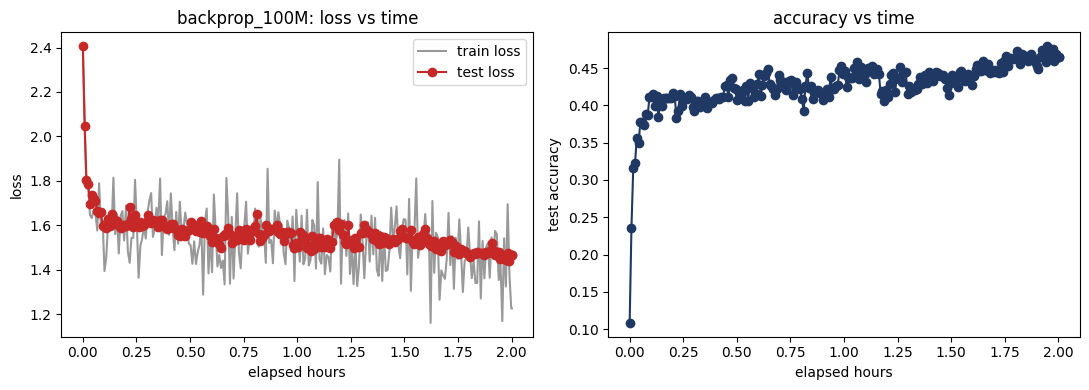

[h=2.00] step=28,947 epoch=37.052 test_loss=1.4658 acc=0.465
wrote /content/drive/MyDrive/Section8_regime1_cifar10/results/backprop_100M.json
DONE backprop_100M: 28,947 steps, 2.00h, final test acc 0.465, best loss 1.4396


In [22]:
def write_results(step, elapsed, logs):
    te = [l[4] for l in logs]; ac = [l[5] for l in logs]
    summary = dict(initial_loss=logs[0][4], final_loss=logs[-1][4], best_loss=min(te),
                   reduction_pct=100*(logs[0][4]-min(te))/max(logs[0][4], 1e-9),
                   final_acc=logs[-1][5], best_acc=max(ac))
    peak = torch.cuda.max_memory_allocated()/1e6 if device == 'cuda' else float('nan')
    out = dict(meta=dict(method=METHOD, device=device, seed=SEED, P=P, config=CFG,
                         note='all MEASURED-here', wall_clock_sec=elapsed, total_steps=step,
                         epochs=step*BATCH/50000, peak_mem_mb=peak),
               curve=dict(t_sec=[l[0] for l in logs], step=[l[1] for l in logs], epoch=[l[2] for l in logs],
                          train_loss=[l[3] for l in logs], test_loss=te, test_acc=ac),
               summary=summary)
    with open(RESULTS_PATH, 'w') as f: json.dump(out, f, indent=2)
    print('wrote', RESULTS_PATH)

def run():
    step, elapsed0, logs = maybe_resume()
    t0 = time.time(); budget = TIME_BUDGET_HOURS*3600
    last_ckpt = last_plot = last_log = last_beat = elapsed0
    if not logs:
        l0, a0 = eval_metrics(); logs.append((elapsed0, step, 0.0, l0, l0, a0))
    tl = logs[-1][3]; step1_printed = False
    while True:
        elapsed = elapsed0 + (time.time() - t0)
        if elapsed >= budget: break
        tl = train_step(); step += 1
        if not step1_printed:
            dt = time.time() - t0
            print(f'[{METHOD}] step 1 = {dt:.2f}s -> ~{int(budget/max(dt,1e-9)):,} steps fit the budget.', flush=True)
            step1_printed = True
        if elapsed - last_log >= LOG_EVERY_SEC:
            el, ac = eval_metrics(); logs.append((elapsed, step, step*BATCH/50000, tl, el, ac)); last_log = elapsed
        if elapsed - last_beat >= HEARTBEAT_EVERY_SEC:
            L = logs[-1]
            print(f'[{METHOD}] h={elapsed/3600:.2f} step={step:,} train={L[3]:.4f} test={L[4]:.4f} acc={L[5]:.3f}', flush=True)
            last_beat = elapsed
        if elapsed - last_ckpt >= CKPT_EVERY_SEC:
            save_checkpoint(step, elapsed, logs); last_ckpt = elapsed
        if elapsed - last_plot >= PLOT_EVERY_SEC:
            live_plot(logs); last_plot = elapsed
    elapsed = elapsed0 + (time.time() - t0)
    el, ac = eval_metrics(); logs.append((elapsed, step, step*BATCH/50000, tl, el, ac))
    save_checkpoint(step, elapsed, logs); live_plot(logs, final=True); write_results(step, elapsed, logs)
    print(f'DONE {METHOD}: {step:,} steps, {elapsed/3600:.2f}h, final test acc {ac:.3f}, best loss {min(l[4] for l in logs):.4f}')

run()

## How to read / run
- **Set `SMOKE=True` first** (Config cell) for a ~20 s end-to-end check, then set it back to `False`.
- **Runtime → Run all.** Watch the hourly live graph; the PNG is also saved to Drive each hour.
- **Disconnect-safe:** it checkpoints every ~2 min to Drive and auto-resumes (counting prior elapsed time) when you re-run.
- Reads back in `04_compare_results.ipynb`. Same `SEED`/arch across all three methods = a fair race.